# Task 02 – Data Cleaning and Exploratory Data Analysis

## Customer Shopping Dataset

### Objective
To perform data cleaning and exploratory data analysis on a customer shopping dataset, explore relationships between variables, and identify meaningful patterns and trends in customer purchasing behavior.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


# File reading

In [5]:
df = pd.read_csv(r"C:\Users\omkar ghogare\Downloads\EDA_Practice_Dataset_1000_Rows.csv")

In [6]:
df.head()

,Customer_ID,Age,Gender,City,Category,Purchase_Amount,Payment_Method,Customer_Segment,Purchase_Channel,Customer_Rating
0,10001,56.0,Female,Pune,Electronics,11434.22,Debit Card,Regular,Store,3.3
1,10002,NaN,Female,Navi Mumbai,Beauty,9222.54,UPI,Premium,Store,4.1
2,10003,32.0,Male,Nashik,Home & Kitchen,NaN,Cash,Regular,Mobile App,1.1
3,10004,60.0,NaN,Mumbai,Grocery,12306.80,Debit Card,Regular,Store,3.2
4,10005,25.0,Male,Thane,Grocery,3941.64,Net Banking,New,Online,4.4


In [15]:
df.tail()

,Customer_ID,Age,Gender,City,Category,Purchase_Amount,Payment_Method,Customer_Segment,Purchase_Channel,Customer_Rating
1000,10001,56.0,Female,Pune,Electronics,11434.22,Debit Card,Regular,Store,3.3
1001,10002,NaN,Female,Navi Mumbai,Beauty,9222.54,UPI,Premium,Store,4.1
1002,10003,32.0,Male,Nashik,Home & Kitchen,NaN,Cash,Regular,Mobile App,1.1
1003,10004,60.0,NaN,Mumbai,Grocery,12306.80,Debit Card,Regular,Store,3.2
1004,10005,25.0,Male,Thane,Grocery,3941.64,Net Banking,New,Online,4.4


In [17]:
df.shape

(1005, 10)

In [20]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Category', 'Purchase_Amount',
       'Payment_Method', 'Customer_Segment', 'Purchase_Channel',
       'Customer_Rating'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       1005 non-null   int64  
 1   Age               994 non-null    float64
 2   Gender            994 non-null    object 
 3   City              995 non-null    object 
 4   Category          1005 non-null   object 
 5   Purchase_Amount   994 non-null    float64
 6   Payment_Method    1005 non-null   object 
 7   Customer_Segment  1005 non-null   object 
 8   Purchase_Channel  1005 non-null   object 
 9   Customer_Rating   995 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 78.6+ KB


In [24]:
df.describe()

,Customer_ID,Age,Purchase_Amount,Customer_Rating
count,1005.000000,994.000000,994.000000,995.000000
mean,10498.024876,38.926559,7717.519386,3.034070
std,290.220129,12.335999,4206.751999,1.157486
min,10001.000000,18.000000,229.870000,1.000000
25%,10247.000000,28.000000,4135.732500,2.100000
50%,10498.000000,40.000000,7845.785000,3.100000
75%,10749.000000,50.000000,11354.745000,4.100000
max,11000.000000,60.000000,14993.250000,5.000000


In [22]:
df.describe(include="object")

,Gender,City,Category,Payment_Method,Customer_Segment,Purchase_Channel
count,994,995,1005,1005,1005,1005
unique,3,8,6,5,3,3
top,Female,Nagpur,Beauty,Debit Card,Regular,Online
freq,490,139,183,211,564,461


In [23]:
df.isnull().sum()

Customer_ID          0
Age                 11
Gender              11
City                10
Category             0
Purchase_Amount     11
Payment_Method       0
Customer_Segment     0
Purchase_Channel     0
Customer_Rating     10
dtype: int64

In [25]:
(df.isnull().sum() / len(df)) * 100

Customer_ID         0.000000
Age                 1.094527
Gender              1.094527
City                0.995025
Category            0.000000
Purchase_Amount     1.094527
Payment_Method      0.000000
Customer_Segment    0.000000
Purchase_Channel    0.000000
Customer_Rating     0.995025
dtype: float64

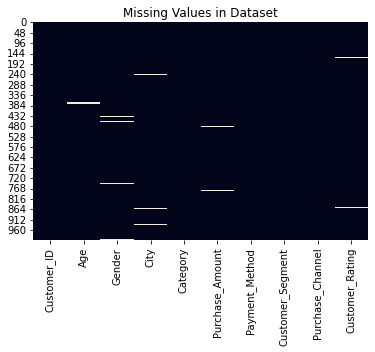

In [7]:
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Dataset")
plt.show()

Observation: The dataset contains missing values in selected numerical and categorical columns. These missing records need to be handled before performing further analysis to ensure accurate results.

# Find Duplicate Rows

In [8]:
df.duplicated().sum()

5

In [9]:
#See the duplicate rows:
df[df.duplicated()]

,Customer_ID,Age,Gender,City,Category,Purchase_Amount,Payment_Method,Customer_Segment,Purchase_Channel,Customer_Rating
1000,10001,56.0,Female,Pune,Electronics,11434.22,Debit Card,Regular,Store,3.3
1001,10002,NaN,Female,Navi Mumbai,Beauty,9222.54,UPI,Premium,Store,4.1
1002,10003,32.0,Male,Nashik,Home & Kitchen,NaN,Cash,Regular,Mobile App,1.1
1003,10004,60.0,NaN,Mumbai,Grocery,12306.80,Debit Card,Regular,Store,3.2
1004,10005,25.0,Male,Thane,Grocery,3941.64,Net Banking,New,Online,4.4


In [17]:
#Remove them:
df = df.drop_duplicates()

In [18]:
#Check again:
df.duplicated().sum()

0

In [19]:
#Check your shape again:
df.shape

(1000, 10)

# Check Missing Values Again

In [22]:
df_clean.isnull().sum()

Customer_ID          0
Age                 10
Gender              10
City                10
Category             0
Purchase_Amount     10
Payment_Method       0
Customer_Segment     0
Purchase_Channel     0
Customer_Rating     10
dtype: int64

In [24]:
#Fill Age:
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

In [25]:
#Fill Purchase Amount:
df_clean["Purchase_Amount"] = df_clean["Purchase_Amount"].fillna(
    df_clean["Purchase_Amount"].median()
)

In [26]:
#Fill Customer Rating:
df_clean["Customer_Rating"] = df_clean["Customer_Rating"].fillna(
    df_clean["Customer_Rating"].median()
)

In [27]:
#Fill Gender:
df_clean["Gender"] = df_clean["Gender"].fillna(
    df_clean["Gender"].mode()[0]
)

In [28]:
#Fill City:
df_clean["City"] = df_clean["City"].fillna(
    df_clean["City"].mode()[0]
)

In [29]:
#Verify Missing Values Are Gone:
df_clean.isnull().sum()

Customer_ID         0
Age                 0
Gender              0
City                0
Category            0
Purchase_Amount     0
Payment_Method      0
Customer_Segment    0
Purchase_Channel    0
Customer_Rating     0
dtype: int64

## Data Cleaning Summary

The dataset initially contained 1,005 records and 10 columns. During the cleaning process, 5 duplicate records were identified and removed, resulting in 1,000 unique records.

The dataset contained missing values in Age, Gender, City, Purchase_Amount, and Customer_Rating. Numerical missing values were handled using the median, while categorical missing values were handled using the mode.

After cleaning, the dataset contains 1,000 records, 10 columns, no duplicate records, and no missing values.

# Numerical Variable Analysis

In [30]:
df_clean[["Age", "Purchase_Amount", "Customer_Rating"]].describe()

,Age,Purchase_Amount,Customer_Rating
count,1000.000000,1000.000000,1000.000000
mean,38.920000,7712.575370,3.033800
std,12.259523,4187.973384,1.151635
min,18.000000,229.870000,1.000000
25%,28.000000,4180.850000,2.100000
50%,40.000000,7826.630000,3.100000
75%,50.000000,11306.517500,4.100000
max,60.000000,14993.250000,5.000000


Age Distribution

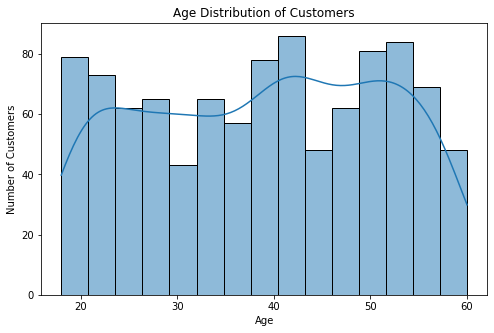

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(data=df_clean, x="Age", bins=15, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

Observation: Customers are distributed across a broad age range of approximately 18 to 60 years. The distribution is relatively spread out, with noticeable concentrations around the early 40s and early 50s

Purchase Amount Distribution

Text(0, 0.5, 'Number of Transactions')

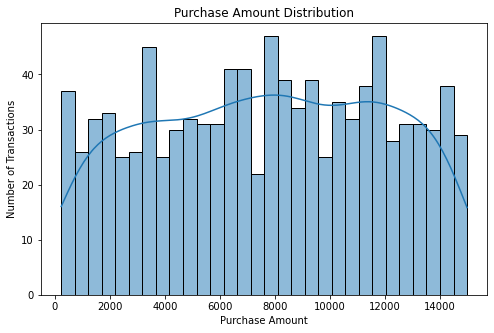

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Purchase_Amount",
    bins=30,
    kde=True
)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Transactions")


Observation: Purchase amounts are distributed across a wide range, with transactions occurring throughout the lower, middle, and higher purchase-value ranges. The distribution does not show a strong concentration around a single purchase amount.

Customer Rating Distribution

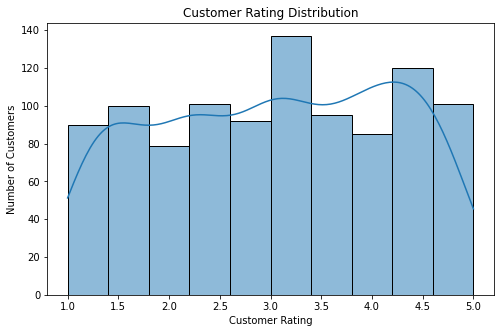

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Customer_Rating",
    bins=10,
    kde=True
)

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Customers")

plt.show()

Observation: Customer ratings are distributed across the full 1–5 scale. Ratings around 3 and 4–4.5 occur relatively frequently, indicating varied customer satisfaction levels.

# Categorical Variable Analysis

Gender Distribution

In [34]:
df_clean["Gender"].value_counts()

Female    498
Male      465
Other      37
Name: Gender, dtype: int64

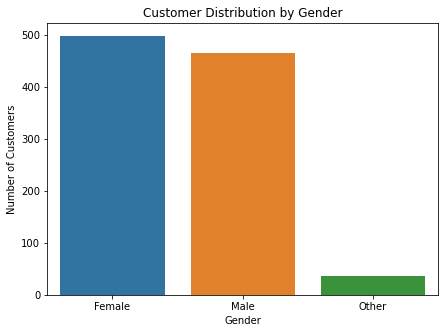

In [35]:
plt.figure(figsize=(7,5))

sns.countplot(data=df_clean, x="Gender")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

Observation: Female customers form the largest group in the dataset, followed by male customers. The number of customers categorized as Other is considerably smaller.

Customer Distribution by City

In [36]:
df_clean["City"].value_counts()

Nagpur         149
Navi Mumbai    136
Aurangabad     128
Mumbai         127
Nashik         120
Thane          118
Kolhapur       113
Pune           109
Name: City, dtype: int64

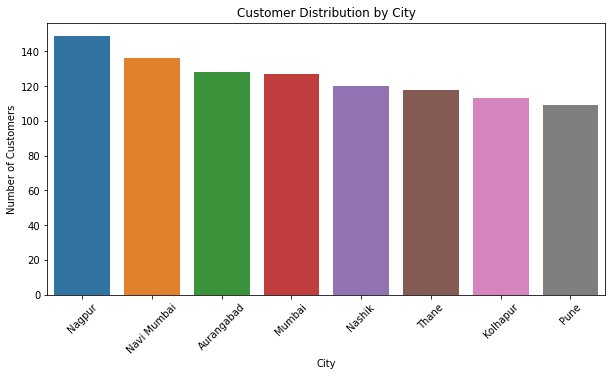

In [37]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="City",
    order=df_clean["City"].value_counts().index
)

plt.title("Customer Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

Observation: Nagpur has the highest number of customers in the dataset, while Pune has the lowest. Customer distribution varies across cities, although the differences are relatively moderate.

Product Category Distribution

In [38]:
df_clean["Category"].value_counts()

Beauty            182
Grocery           175
Electronics       171
Home & Kitchen    171
Clothing          151
Sports            150
Name: Category, dtype: int64

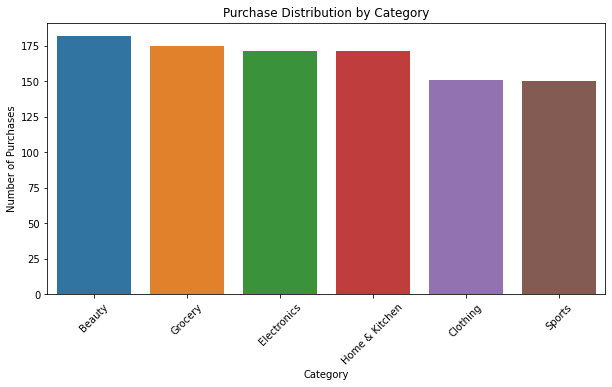

In [39]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Category",
    order=df_clean["Category"].value_counts().index
)

plt.title("Purchase Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.show()

Observation: Beauty has the highest number of purchases among the product categories, while Sports has the lowest. Overall, purchase volumes are relatively balanced across most categories.

Payment Method Distribution

# Revenue by Category

In [40]:
df_clean["Payment_Method"].value_counts()

Debit Card     209
Cash           207
Net Banking    204
Credit Card    194
UPI            186
Name: Payment_Method, dtype: int64

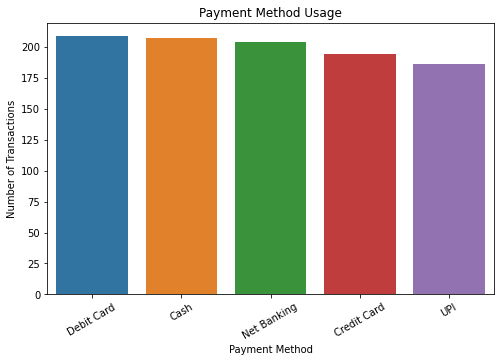

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Payment_Method",
    order=df_clean["Payment_Method"].value_counts().index
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.show()

Observation: Debit Card is the most frequently used payment method, followed closely by Cash and Net Banking. UPI has the lowest number of transactions among the available payment methods.

Customer Segment Distribution

In [44]:
df_clean["Customer_Segment"].value_counts()

Regular    561
Premium    242
New        197
Name: Customer_Segment, dtype: int64

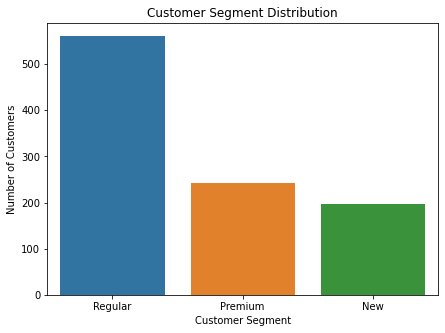

In [45]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Customer_Segment",
    order=df_clean["Customer_Segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

Observation: Regular customers represent the largest customer segment, while Premium and New customers account for smaller portions of the dataset. This indicates that the dataset is dominated by existing regular customers.

Purchase Channel Distribution

In [46]:
df_clean["Purchase_Channel"].value_counts()

Online        460
Store         316
Mobile App    224
Name: Purchase_Channel, dtype: int64

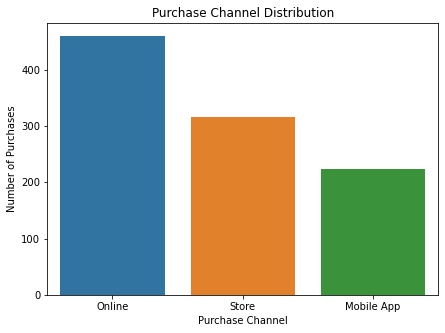

In [47]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Purchase_Channel",
    order=df_clean["Purchase_Channel"].value_counts().index
)

plt.title("Purchase Channel Distribution")
plt.xlabel("Purchase Channel")
plt.ylabel("Number of Purchases")

plt.show()

Observation: Online is the most frequently used purchase channel, followed by Store and Mobile App. This indicates that customers in the dataset prefer online purchasing over physical store and mobile app purchases.

# Bivariate Analysis

Bivariate analysis is used to examine the relationship between two variables and identify patterns in customer purchasing behavior.

Age vs Purchase Amount

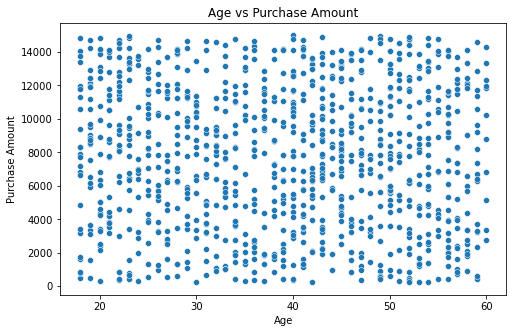

In [48]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Age",
    y="Purchase_Amount"
)

plt.title("Age vs Purchase Amount")
plt.xlabel("Age")
plt.ylabel("Purchase Amount")

plt.show()

Observation: The scatter plot shows a weak or no obvious relationship between age and purchase amount. Customers across different age groups make both low-value and high-value purchases, suggesting that age alone does not strongly determine purchase amount in this dataset.

Gender vs Purchase Amount

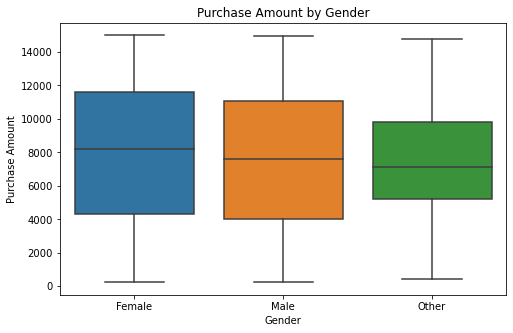

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Gender",
    y="Purchase_Amount"
)

plt.title("Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount")

plt.show()

Observation: The box plot shows some variation in purchase amounts across gender groups, with Female customers having a slightly higher median purchase amount. However, the distributions overlap considerably, indicating that gender does not create a major difference in purchase amount.

Category vs Purchase Amount

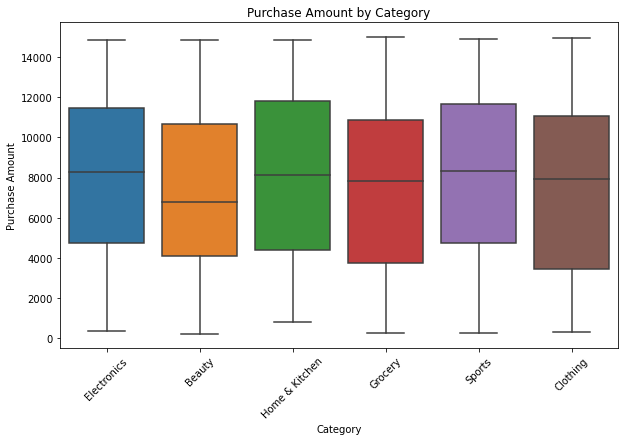

In [50]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="Category",
    y="Purchase_Amount"
)

plt.title("Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Purchase Amount")

plt.xticks(rotation=45)

plt.show()

Observation: The box plot shows differences in purchase amounts across categories, with Home & Kitchen and Electronics having relatively higher median values. However, the distributions overlap considerably across categories.

Revenue by Category

In [51]:
category_revenue = (
    df_clean.groupby("Category")["Purchase_Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Category
Home & Kitchen    1377742.82
Electronics       1367499.07
Beauty            1320287.14
Grocery           1309006.96
Sports            1199195.68
Clothing          1138843.70
Name: Purchase_Amount, dtype: float64

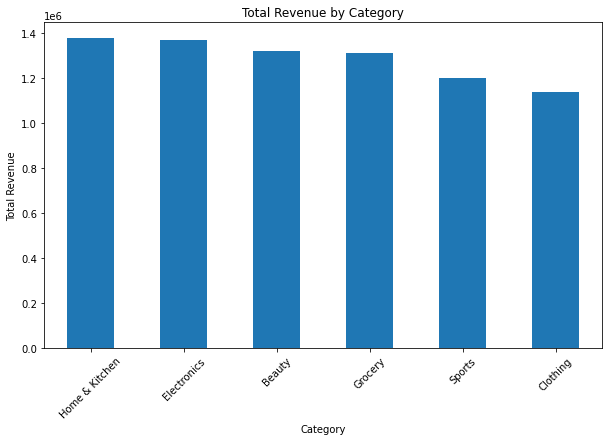

In [52]:
plt.figure(figsize=(10,6))

category_revenue.plot(kind="bar")

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

Observation: The category-wise revenue analysis shows that Home & Kitchen generates the highest total revenue, while Clothing generates the lowest. This indicates that Home & Kitchen is an important contributor to overall revenue in the dataset.

Revenue by City

In [53]:
city_revenue = (
    df_clean.groupby("City")["Purchase_Amount"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue

City
Nagpur         1132495.79
Aurangabad     1094302.23
Navi Mumbai    1066042.88
Mumbai         1002198.18
Kolhapur        911623.87
Nashik          908206.55
Thane           861061.79
Pune            736644.08
Name: Purchase_Amount, dtype: float64

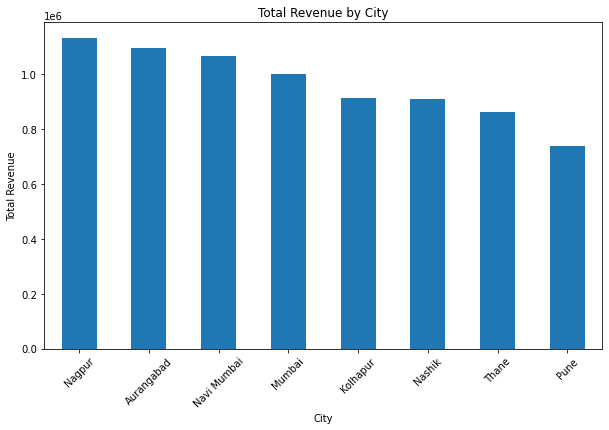

In [54]:
plt.figure(figsize=(10,6))

city_revenue.plot(kind="bar")

plt.title("Total Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

Observation: The city-wise revenue analysis shows that Nagpur is the highest revenue-generating city, while Pune contributes the least revenue. This highlights differences in revenue contribution across locations.

Customer Segment vs Purchase Amount

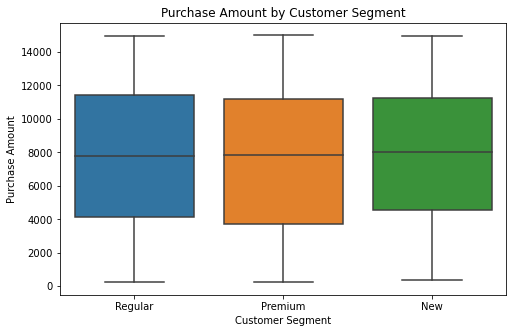

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Customer_Segment",
    y="Purchase_Amount"
)

plt.title("Purchase Amount by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Purchase Amount")

plt.show()

Observation: The box plot shows that purchase amounts are relatively similar across customer segments, with comparable median values. This suggests that customer segment does not create a major difference in individual purchase amount.

In [56]:
segment_revenue = (
    df_clean.groupby("Customer_Segment")["Purchase_Amount"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Customer_Segment
Regular    4318447.78
Premium    1837621.84
New        1556505.75
Name: Purchase_Amount, dtype: float64

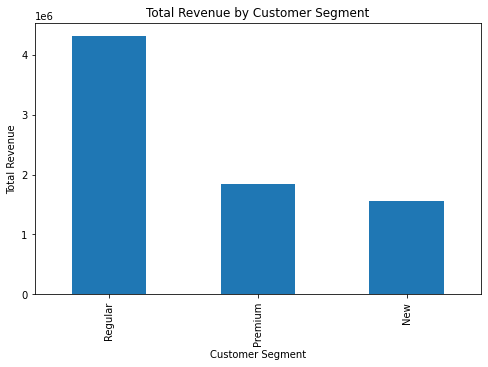

In [57]:
plt.figure(figsize=(8,5))

segment_revenue.plot(kind="bar")

plt.title("Total Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.show()

Observation: The customer segment revenue analysis shows that Regular customers contribute the highest total revenue by a large margin, while New customers contribute the least. This is likely influenced by the larger number of Regular customers in the dataset.

Payment Method vs Purchase Amount

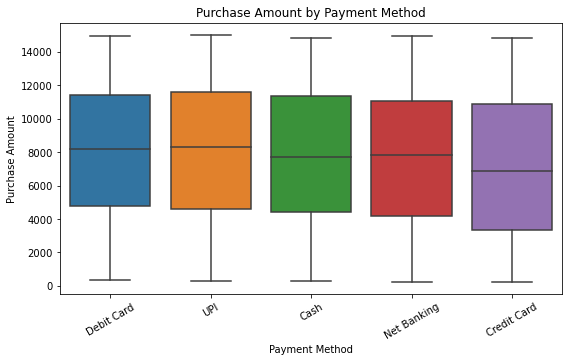

In [58]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_clean,
    x="Payment_Method",
    y="Purchase_Amount"
)

plt.title("Purchase Amount by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Purchase Amount")

plt.xticks(rotation=30)

plt.show()

Observation: The box plot indicates some differences in purchase amounts across payment methods, with UPI and Debit Card showing relatively higher median values. However, the distributions overlap considerably.

In [59]:
payment_average = (
    df_clean.groupby("Payment_Method")["Purchase_Amount"]
    .mean()
    .sort_values(ascending=False)
)

payment_average

Payment_Method
UPI            8065.170269
Debit Card     7900.633158
Cash           7786.100918
Net Banking    7652.047010
Credit Card    7157.117990
Name: Purchase_Amount, dtype: float64

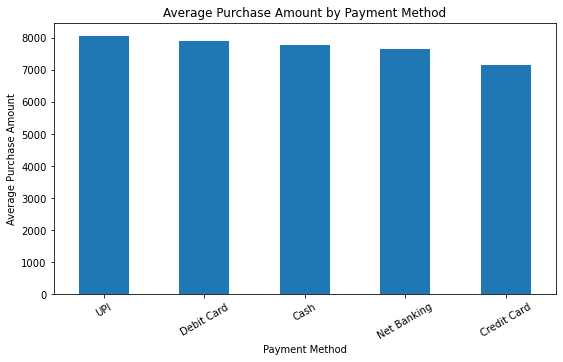

In [60]:
plt.figure(figsize=(9,5))

payment_average.plot(kind="bar")

plt.title("Average Purchase Amount by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Purchase Amount")

plt.xticks(rotation=30)

plt.show()

Observation: The average purchase amount is highest for UPI transactions and lowest for Credit Card transactions. This suggests that UPI users tend to make relatively higher-value purchases in this dataset.

Purchase Channel vs Purchase Amount

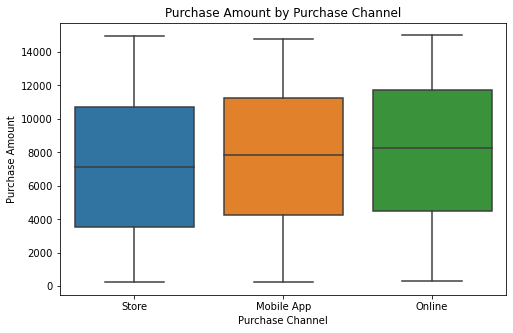

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Purchase_Channel",
    y="Purchase_Amount"
)

plt.title("Purchase Amount by Purchase Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Purchase Amount")

plt.show()

Observation: The box plot shows that Online purchases have the highest median purchase amount, while Store purchases have the lowest. This suggests that customers using the Online channel tend to make relatively higher-value purchases.

In [62]:
channel_average = (
    df_clean.groupby("Purchase_Channel")["Purchase_Amount"]
    .mean()
    .sort_values(ascending=False)
)

channel_average

Purchase_Channel
Online        8073.188739
Mobile App    7574.357054
Store         7285.609399
Name: Purchase_Amount, dtype: float64

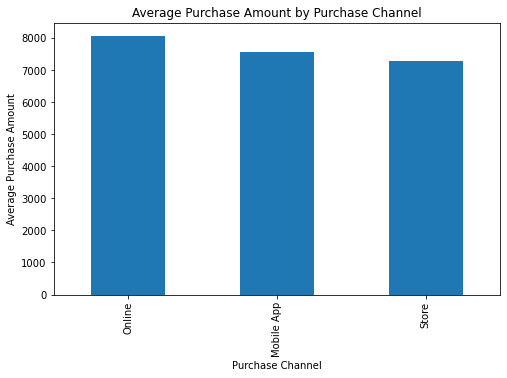

In [63]:
plt.figure(figsize=(8,5))

channel_average.plot(kind="bar")

plt.title("Average Purchase Amount by Purchase Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Average Purchase Amount")

plt.show()

Observation: The average purchase amount is highest for the Online channel and lowest for the Store channel. This indicates that Online customers tend to make higher-value purchases on average.

# Correlation Analysis

In [64]:
correlation = df_clean[
    ["Age", "Purchase_Amount", "Customer_Rating"]
].corr()

correlation

,Age,Purchase_Amount,Customer_Rating
Age,1.000000,-0.036577,0.018654
Purchase_Amount,-0.036577,1.000000,0.013897
Customer_Rating,0.018654,0.013897,1.000000


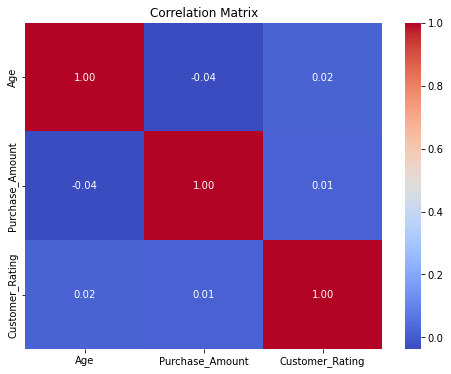

In [65]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Observation: The correlation matrix shows very weak linear relationships between Age, Purchase Amount, and Customer Rating. The results suggest that none of these numerical variables has a strong linear association with the others in this dataset.

# Outlier Analysis

Purchase Amount

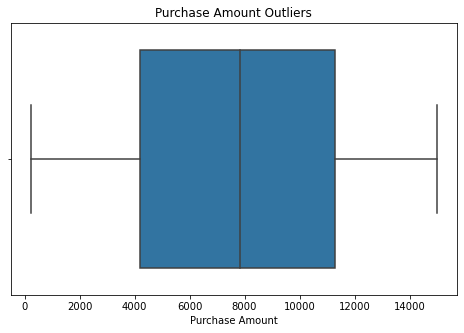

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Purchase_Amount"
)

plt.title("Purchase Amount Outliers")
plt.xlabel("Purchase Amount")

plt.show()

Observation: The box plot does not show any significant observations beyond the whiskers, suggesting that there are no apparent extreme outliers in Purchase Amount.

Age

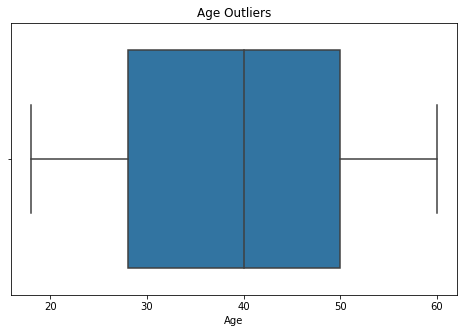

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Age"
)

plt.title("Age Outliers")
plt.xlabel("Age")

plt.show()

Observation: The box plot shows no apparent extreme outliers in Age, indicating that the customer ages fall within a relatively consistent range.

Customer Rating

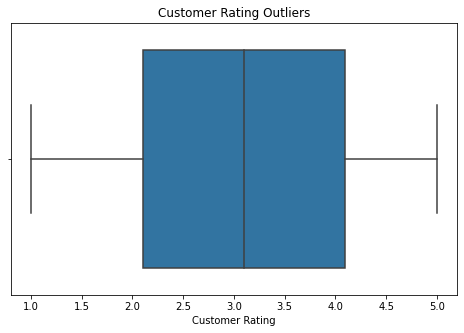

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Customer_Rating"
)

plt.title("Customer Rating Outliers")
plt.xlabel("Customer Rating")

plt.show()

Observation: The box plot shows no apparent extreme outliers in Customer Rating, indicating that the ratings remain within the expected range.

# Overall Revenue Analysis

Total Revenue

In [70]:
total_revenue = df_clean["Purchase_Amount"].sum()

total_revenue

7712575.369999999

Average Purchase

In [71]:
average_purchase = df_clean["Purchase_Amount"].mean()

average_purchase

7712.575369999998

Maximum Purchase

In [72]:
maximum_purchase = df_clean["Purchase_Amount"].max()

maximum_purchase

14993.25

Minimum Purchase

In [73]:
minimum_purchase = df_clean["Purchase_Amount"].min()

minimum_purchase

229.87

In [74]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Purchase",
        "Maximum Purchase",
        "Minimum Purchase"
    ],
    "Value": [
        total_revenue,
        average_purchase,
        maximum_purchase,
        minimum_purchase
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,7.712575e+06
1,Average Purchase,7.712575e+03
2,Maximum Purchase,1.499325e+04
3,Minimum Purchase,2.298700e+02


## Key Business Insights

1. Online is the most frequently used purchase channel and also has the highest average purchase amount.

2. Regular customers form the largest customer segment and contribute the highest total revenue.

3. Home & Kitchen generates the highest total revenue among all product categories.

4. Nagpur is the highest revenue-generating city in the dataset.

5. Beauty has the highest number of purchases, indicating strong customer demand for this category.

6. UPI has the highest average purchase amount among the payment methods.

7. Purchase amounts vary considerably across customers, categories, payment methods, and purchase channels.

8. Age does not show an obvious strong linear relationship with purchase amount.

9. Customer Rating has very weak correlation with Age and Purchase Amount.

10. No apparent extreme outliers were detected in Age, Purchase Amount, or Customer Rating.

## Conclusion

The exploratory data analysis helped identify important patterns in customer purchasing behavior. The analysis shows differences in customer preferences across purchase channels, categories, cities, payment methods, and customer segments. Online purchases have relatively higher average values, while Regular customers contribute the largest share of revenue. Home & Kitchen is the highest revenue-generating category, and Nagpur contributes the highest city-wise revenue. Overall, the dataset provides useful insights into customer behavior and spending patterns.